In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 6,
        "axes.titlesize": 6,
        "axes.labelsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "figure.titlesize": 6,
        "figure.dpi": 200,
        "axes.linewidth": 0.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",
    }
)

Gene-group comparison

In [2]:
# Load data
data_df = pd.read_csv("data/Neville2025_sperm_mutation_count.with_site.tsv", sep="\t")
data_df = data_df.dropna(subset=["non_nsite", "mis_nsite", "ssite"])

# Load gene sets
DD_gene_set = [
    line.strip() for line in open("../Fig4/data/denovoWEST_DD-related_gene.lst", "r")
]
ASD_gene_set = [line.strip() for line in open("../Fig4/data/ASD-related_gene.lst", "r")]
cRDH_gene_set = [
    line.strip()
    for line in open("../Fig4/data/human_cRDH_gene.gencodev44.lst", "r")
    if "H1" not in line
]

# Annotate
data_df["is_DD"] = data_df["gene"].map(lambda x: x in DD_gene_set)
data_df["is_ASD"] = data_df["gene"].map(lambda x: x in ASD_gene_set)
data_df["is_cRDHGs"] = data_df["gene"].map(lambda x: x in cRDH_gene_set)
data_df["is_OG"] = data_df.apply(
    lambda row: (not row["is_DD"]) and (not row["is_ASD"]) and (not row["is_cRDHGs"]),
    axis=1,
)

In [3]:
df_dic_lst = []

# Calculate dN/dS for each gene type
for gene_type in ["cRDHGs", "ASD", "DD", "OG"]:

    sub_df = data_df[data_df[f"is_{gene_type}"]]
    gene_num = len(sub_df)

    nsite_mis_sum = sub_df["mis_nsite"].sum()
    nsite_non_sum = sub_df["non_nsite"].sum()
    ssite_sum = sub_df["ssite"].sum()

    mis_sum = sub_df["sperm_mis"].sum()
    non_sum = sub_df["sperm_stopgain"].sum()
    syn_sum = sub_df["sperm_syn"].sum()

    dnds_mis = (mis_sum / nsite_mis_sum) / (syn_sum / ssite_sum)
    dnds_non = (non_sum / nsite_non_sum) / (syn_sum / ssite_sum)

    df_dic_lst.append(
        {
            "Gene type": gene_type,
            "Gene number": gene_num,
            "mis count": mis_sum,
            "non count": non_sum,
            "syn count": syn_sum,
            "dN/dS (Missense)": dnds_mis,
            "dN/dS (Nonsense)": dnds_non,
        }
    )

plot_df = pd.DataFrame(df_dic_lst)
plot_df["Gene type"] = plot_df["Gene type"].map(
    {
        "cRDHGs": "core RDHs",
        "OG": "Other genes",
        "DD": "DD-related",
        "ASD": "ASD-related",
    }
)

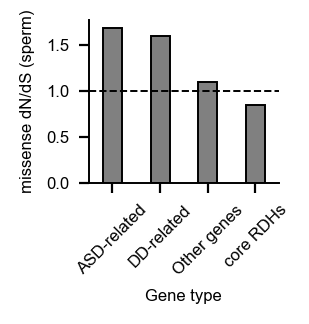

In [4]:
# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.6))

sns.barplot(
    data=plot_df,
    x="Gene type",
    y="dN/dS (Missense)",
    order=[
        "ASD-related",
        "DD-related",
        "Other genes",
        "core RDHs",
    ],
    color="gray",
    width=0.4,
    edgecolor="black",
    linewidth=0.7,
)

ax.xaxis.set_tick_params(rotation=45)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(y=1, color="black", linestyle="--", linewidth=0.7)
ax.set_ylabel("missense dN/dS (sperm)")

plt.tight_layout()

HistMTR bins comparison

In [5]:
# Read mutation information for all possible mutations in RDH genes
df = pd.read_csv(
    "../Fig4/data/RDH_all_possible_mis_syn_mutation_annotated.tsv", sep="\t"
)
df = df[df["no-gap consensus idx"] != "-"]
df["no-gap consensus idx"] = df["no-gap consensus idx"].astype(int)

In [6]:
from collections import defaultdict

# Annotate sperm mutations
sperm_mut_count = defaultdict(int)
with open("data/Neville2025_SupTable7_SpermExomeTargVars.hg38.vcf", "r") as f:
    for line in f:
        fields = line.strip().split("\t")
        chr, pos, _, ref, alt, _, filter_status, info = fields[:8]
        uid = f"{chr}:{pos}:{ref}>{alt}"
        sperm_mut_count[uid] += 1


def annotate_sperm_mutation(row):
    chrom = row["chr"]
    pos = row["pos"]
    ref = row["ref"]
    alt = row["alt"]
    uid = f"{chrom}:{pos}:{ref}>{alt}"
    return sperm_mut_count.get(uid, 0)


df["sperm_mut_count"] = df.apply(annotate_sperm_mutation, axis=1)

In [7]:
mis_df = df[df["consequence"] == "nonsynonymous SNV"].copy()
syn_df = df[df["consequence"] == "synonymous SNV"].copy()

DNM_COL = "sperm_mut_count"
syn_DNM = syn_df[DNM_COL].sum()
syn_site = syn_df["mutation rate"].sum()

rows = []
# Add category
mis_df["bin"] = pd.qcut(mis_df["HistMTR"], q=3, labels=False, duplicates="drop")

for bin_id, sub_df in mis_df.groupby("bin"):

    mis_DNM = sub_df[DNM_COL].sum()
    mis_site = sub_df["mutation rate"].sum()
    dn_ds = (mis_DNM / mis_site) / (syn_DNM / syn_site)
    max_histoneMTR = sub_df["HistMTR"].max()
    # print(f"Bin {bin_id}: dN/dS = {dn_ds:.2f}")
    rows.append(
        {
            "bin": bin_id,
            "max HistMTR": max_histoneMTR,
            "mis_DNM": mis_DNM,
            "mis_site": mis_site,
            "syn_DNM": syn_DNM,
            "syn_site": syn_site,
            "dN/dS": dn_ds,
        }
    )

bin_df = pd.DataFrame(rows)

/tmp/ipykernel_189303/2505680022.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_label, rotation=45)


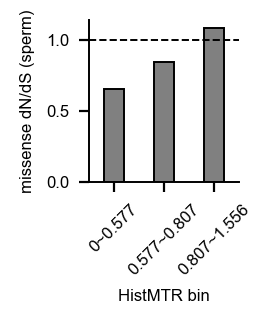

In [8]:
fig, ax = plt.subplots(figsize=(1.3, 1.6))

sns.barplot(
    data=bin_df,
    x="bin",
    y="dN/dS",
    color="gray",
    edgecolor="black",
    linewidth=0.7,
    width=0.4,
)
x_label = []
prev_value = 0
for idx, row in bin_df.iterrows():
    if prev_value == 0:
        x_label.append(f"0~{row['max HistMTR']:.3f}")
    else:
        x_label.append(f"{prev_value:.3f}~{row['max HistMTR']:.3f}")
    prev_value = row["max HistMTR"]

ax.set_xticklabels(x_label, rotation=45)
ax.spines[["top", "right"]].set_visible(False)

ax.axhline(y=1, color="black", linestyle="--", linewidth=0.7)
ax.set_ylabel("missense dN/dS (sperm)")
ax.set_xlabel("HistMTR bin")

plt.tight_layout()